# Chapter 1 problems

This notebook contains the problems from [Chapter 1 Data](https://minireference.com/static/excerpts/noBSstats_part1_preview.pdf#page=12)
in the **No Bullshit Guide to Statistics**.

### Notebooks setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Figures setup
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
    rc={"figure.figsize": (5, 2)},

)

%config InlineBackend.figure_format = 'retina'

In [3]:
# Set pandas precision
pd.set_option("display.precision", 2)

In [4]:
# Simple float __repr__
import numpy as np
if int(np.__version__.split(".")[0]) >= 2:
    np.set_printoptions(legacy='1.25')

In [5]:
# Download datasets/ directory if necessary
from ministats import ensure_datasets
ensure_datasets()

datasets/ directory present and ready.


### Problem {prob:bar-chart_score-vs-curriculum}

In [6]:
import pandas as pd
students = pd.read_csv("datasets/students.csv")

# bar plot

<!-- solution -->
The above bar plot compares the mean `score` between the `debate` and `lecture` curriculum variants.
The error bars stretch from $\textbf{mean} - \textbf{std}$
to $\textbf{mean} + \textbf{std}$ within each group,
and provide an idea of the data variability.

### P?

Melt wide data in `datasets/markswide.csv` into long data.

In [8]:
import pandas as pd
markswide = pd.read_csv("datasets/markswide.csv")

# use the .melt() method and set the options `id_vars`, `var_name`, and `value_name`

### P?

convert bpwide to bplong

In [10]:
import pandas as pd
bpwide = pd.read_csv("datasets/bpwide.csv")
bpwide.head(3)

# use the .melt() method and set the options `id_vars`, `var_name`, and `value_name`

,patient,sex,agegrp,bp_before,bp_after
0,1,Male,30-45,143,153
1,2,Male,30-45,163,170
2,3,Male,30-45,153,168


<!-- solution -->
The first three columns contain identifying variables for a particular individual

### P

In [16]:
z = 5
xs = pd.Series([10, 10-z, 10+z], name="x")
xs.mean(), xs.std()

(10.0, 5.0)

### P?

Draw a scatter plot for the following dataset of (x,y) pairs:
\{ (2,2), (3,3), (4,3), (5,5), (6,4) \}.

### P

We want to summarize the dataset $\mathbf{x}_z = (1, 2, 3, 4, 5, z)$
by reporting a the mean $\mathbf{mean}(\mathbf{x})$,
the standard deviation $\mathbf{std}(\mathbf{x})$,
and the median $\mathbf{med}(\mathbf{x})$.

In [21]:
import pandas as pd
xs10 = pd.Series([1, 2, 3, 4, 5, 10], name="x")

# a) compute the mean, the standard deviation, and the median


### P?

Load the doctors dataset and compute
the following conditional relative frequencies.

a) rur | cli

b) cli | rur 




In [26]:
doctors = pd.read_csv("datasets/doctors.csv")


### P?
 
The data file `datasets/formats/students_meta.csv`
contains metadata as the first four lines of the file:

```
# title: Student's dataset with metadata rows
# description: A copy of students.csv with extra metadata rows at the top
# author: Ivan Savov
# date: 2026-03-25
student_ID,background,curriculum,effort,score
1,arts,debate,10.96,75
2,science,lecture,8.69,75
3,arts,debate,8.6,67
... 12 more lines ...
```

This is not a standard CSV file,
and you'll get an error if you try loading it using `pd.read_csv` with no options.
Consult the help docs for the function `pd.read_csv`
to find an option that skips the metadata rows,
and load the data below them.

Hint: Use `help(pd.read_csv)`, `pd.read_csv?`, or the online docs at [https://pandas.pydata.org/docs/](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html).

Hint: There are at least two options you can use to skip the metadata rows.

In [29]:

# # This doesn't work:
# students_meta = pd.read_csv("datasets/formats/students_meta.csv")

# Read the `pd.read_csv` help docs to find

<!-- solution -->
One approach you can use is the add the option `comment="#"`,
which tells `pd.read_csv` to ignore all rows starting with `#`.
This is similar to how Python ignores comments.

<!-- solution -->
Another approach is to use the option `skiprows=4`,
which tells `pd.read_csv` to skip the first four rows
and start reading the data file only at line `5`,
which is the header row.

### P?

Old Faithful geyser 

Eruption and waiting time of Old Faithful Geyser


In [33]:
faithful = pd.read_csv("datasets/faithful.csv")
faithful.shape
# faithful.sort_values("waiting")
faithful

,duration,waiting
0,3.60,79
1,1.80,54
2,3.33,74
3,2.28,62
4,4.53,85
...,...,...
267,4.12,81
268,2.15,46
269,4.42,90
270,1.82,46


In [34]:
faithful["duration"].describe()

count    272.00
mean       3.49
std        1.14
min        1.60
25%        2.16
50%        4.00
75%        4.45
max        5.10
Name: duration, dtype: float64

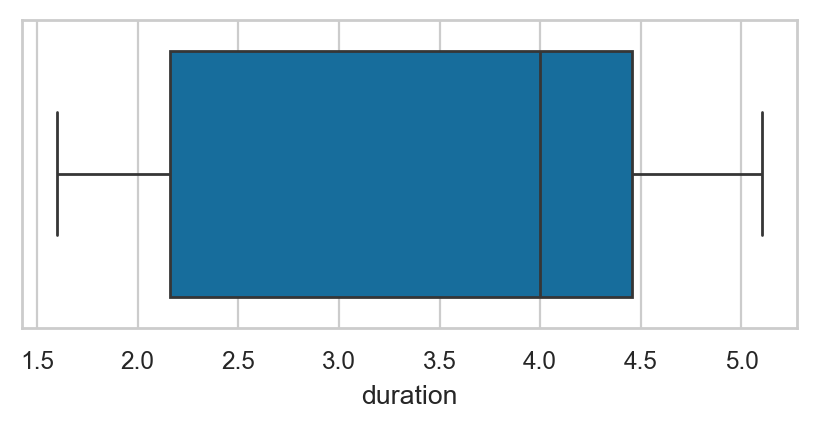

In [35]:
sns.boxplot(data=faithful, x="duration");

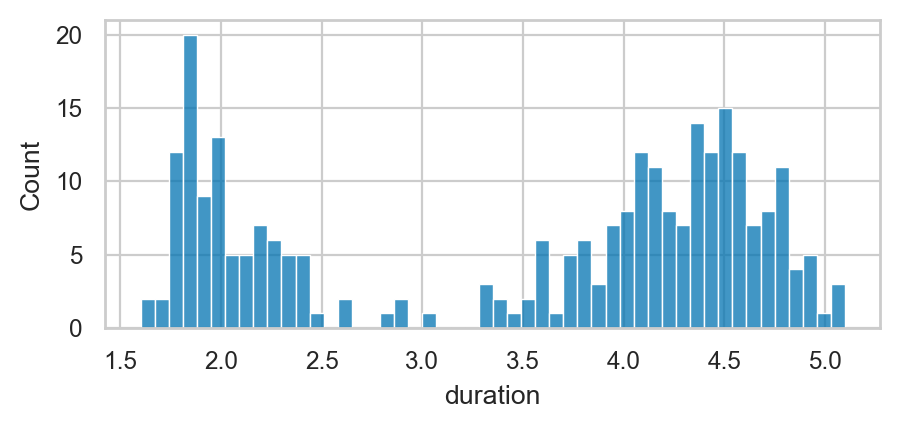

In [36]:
sns.histplot(data=faithful, x="duration", bins=50);

In [37]:
faithful["duration"].min(), faithful["duration"].max()

(1.6, 5.1)

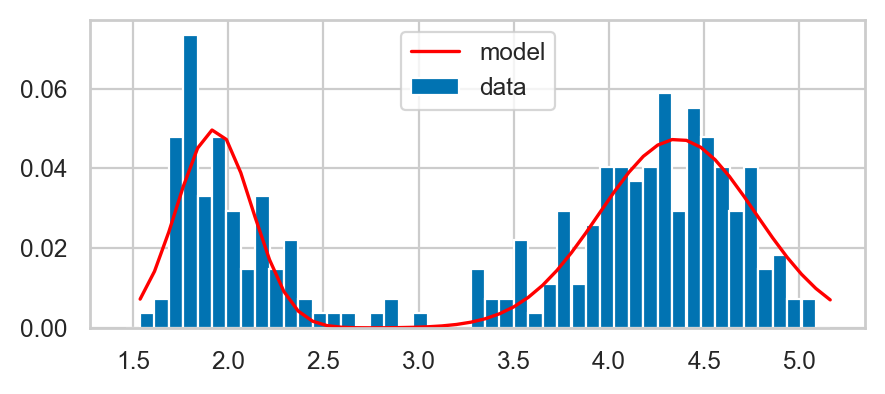

In [38]:
import numpy as np

# histogram
bins = np.linspace(1.5, 5.2, 50)
hist = pd.cut(faithful["duration"], bins=bins, right=False) \
         .value_counts(sort=False, normalize=True)
bins_left = hist.index.categories.left
bins_width = hist.index.categories.length
x = hist.index.categories.mid
y = hist.values


# fit a mixture of Gaussians to the histogram
from scipy.optimize import curve_fit

def gauss(x, mu, sigma, A):
    return A*np.exp(-0.5*(x-mu)**2/sigma**2)

def bimodal(x, mu1, sigma1, A1, mu2, sigma2, A2):
    return gauss(x,mu1,sigma1,A1) + gauss(x,mu2,sigma2,A2)

p0 = (2,0.5,0.4,  4.5,0.5,0.6)
params, cov = curve_fit(bimodal, x, y, p0=p0)
plt.bar(x=bins_left, width=bins_width, height=y, label='data')
plt.plot(x, bimodal(x,*params), color='red', label='model')
plt.legend();
# params

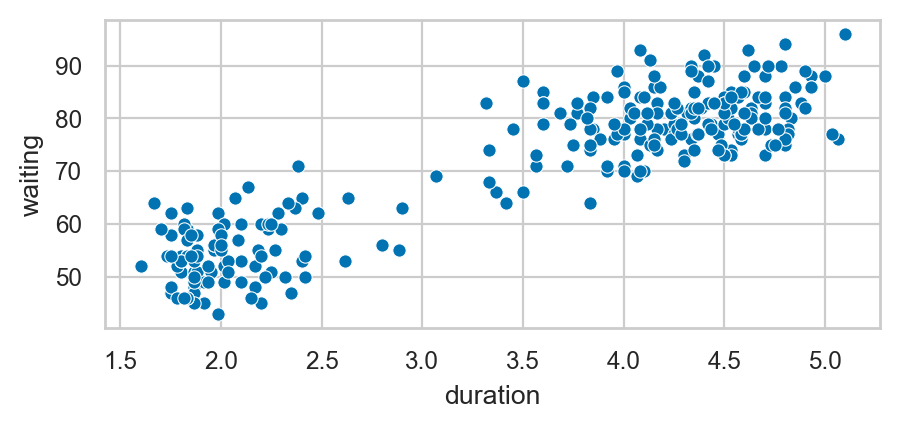

In [39]:
sns.scatterplot(data=faithful, x="duration", y="waiting");

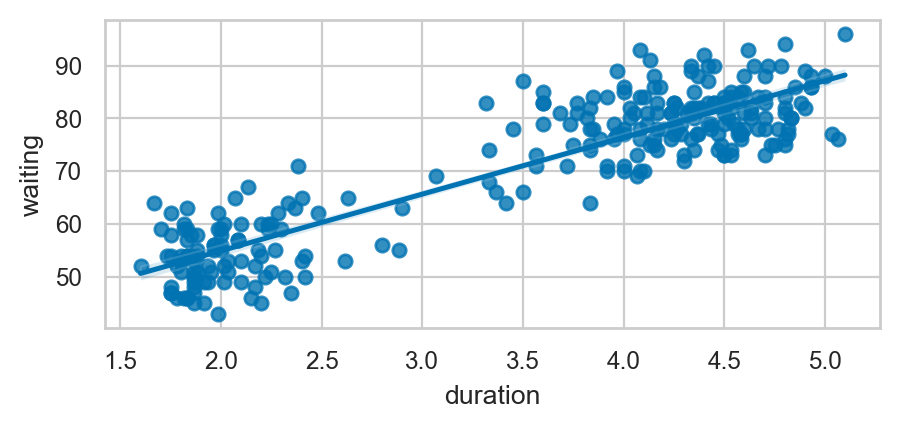

In [40]:
sns.regplot(data=faithful, x="duration", y="waiting");